## 7.12 유니타리 결합 클러스터(UCC)를 이용한 양자 화학 시뮬레이션

In [1]:
# Qiskit 라이브러리 임포트
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_algorithms import VQE
from qiskit.circuit.library import EfficientSU2
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_histogram, plot_state_qsphere, plot_state_city
from qiskit.quantum_info import partial_trace
from qiskit.primitives import StatevectorEstimator  # 호환성 수정: V1 Estimator → V2 StatevectorEstimator
from qiskit.circuit import ParameterVector
import numpy as np
from qiskit_algorithms.utils import algorithm_globals


import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# 백엔드 정의
backend = AerSimulator()

In [3]:
# 회로의 큐비트 수
num_qubits = 4

In [4]:
# 앤사츠(EfficientSU2) 회로 생성
ucc_ansatz = EfficientSU2(num_qubits)

/sessions/eloquent-vigilant-lovelace/tmp/ipykernel_6/666907634.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ucc_ansatz = EfficientSU2(num_qubits)


In [5]:
# 앤사츠 회로의 실제 파라미터 가져오기
param_values = ucc_ansatz.parameters

In [6]:
# 무작위 값의 개수를 회로 파라미터 수와 일치시킴
param_dict = {param: np.random.random() for param in param_values}

In [7]:
# 회로 자체의 파라미터 결합
ucc_circuit = ucc_ansatz.assign_parameters(param_dict)

In [8]:
# AerSimulator가 지원하는 기저 게이트로 회로 트랜스파일
ucc_circuit = transpile(ucc_circuit, backend)

In [9]:
# 초기 상태
initial_state = Statevector.from_label('0' * num_qubits)

In [10]:
# 트랜스파일된 회로로 상태 진화
final_state = initial_state.evolve(ucc_circuit)

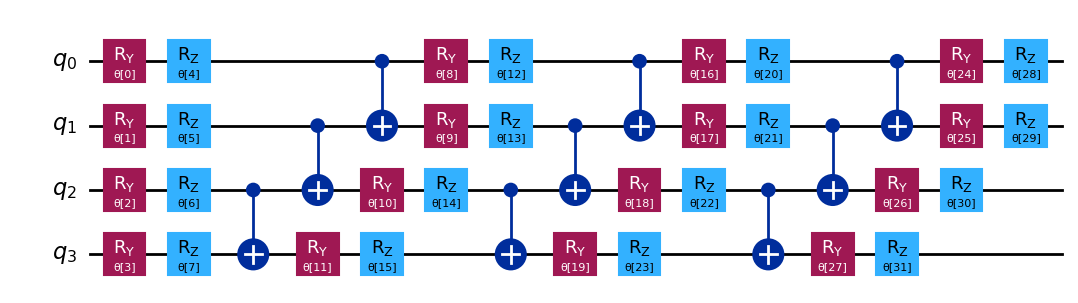

In [11]:
# MPL 회로 시각화
ucc_ansatz.decompose().draw('mpl')
plt.show()

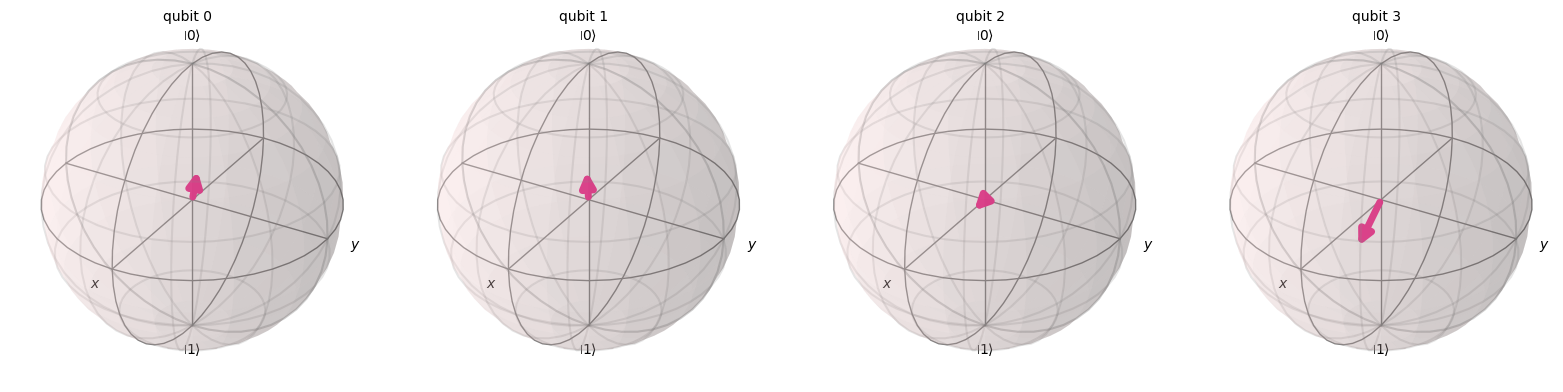

In [12]:
# 블로흐 다중벡터 플롯
plot_bloch_multivector(final_state.data)
plt.show()

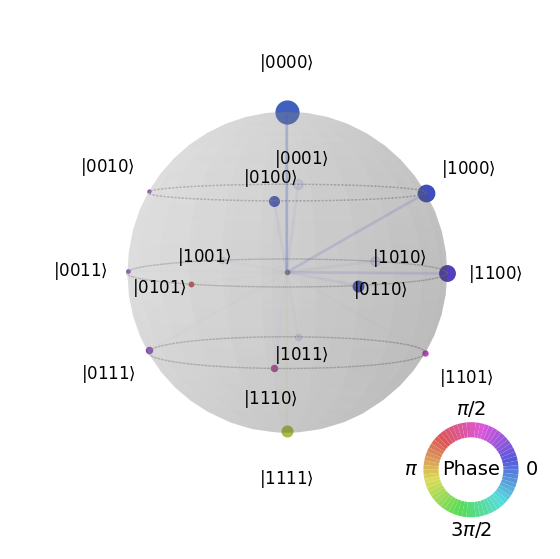

In [13]:
# QSphere 시각화
plot_state_qsphere(final_state.data)
plt.show()

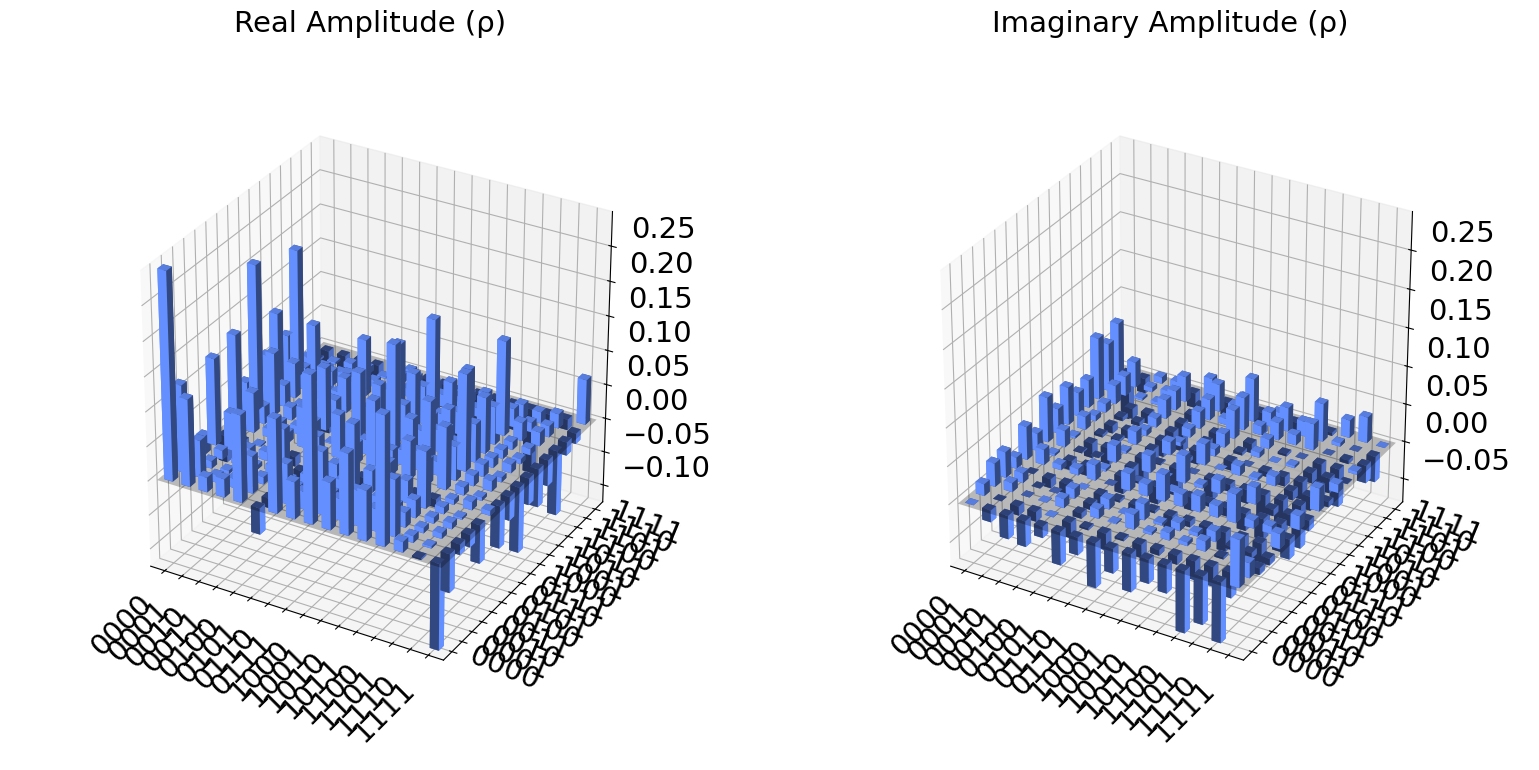

In [14]:
# State City 시각화
plot_state_city(final_state.data)
plt.show()

In [15]:
# 축소 밀도행렬을 위한 부분 대각합
reduced_density_matrix = partial_trace(final_state, [0])

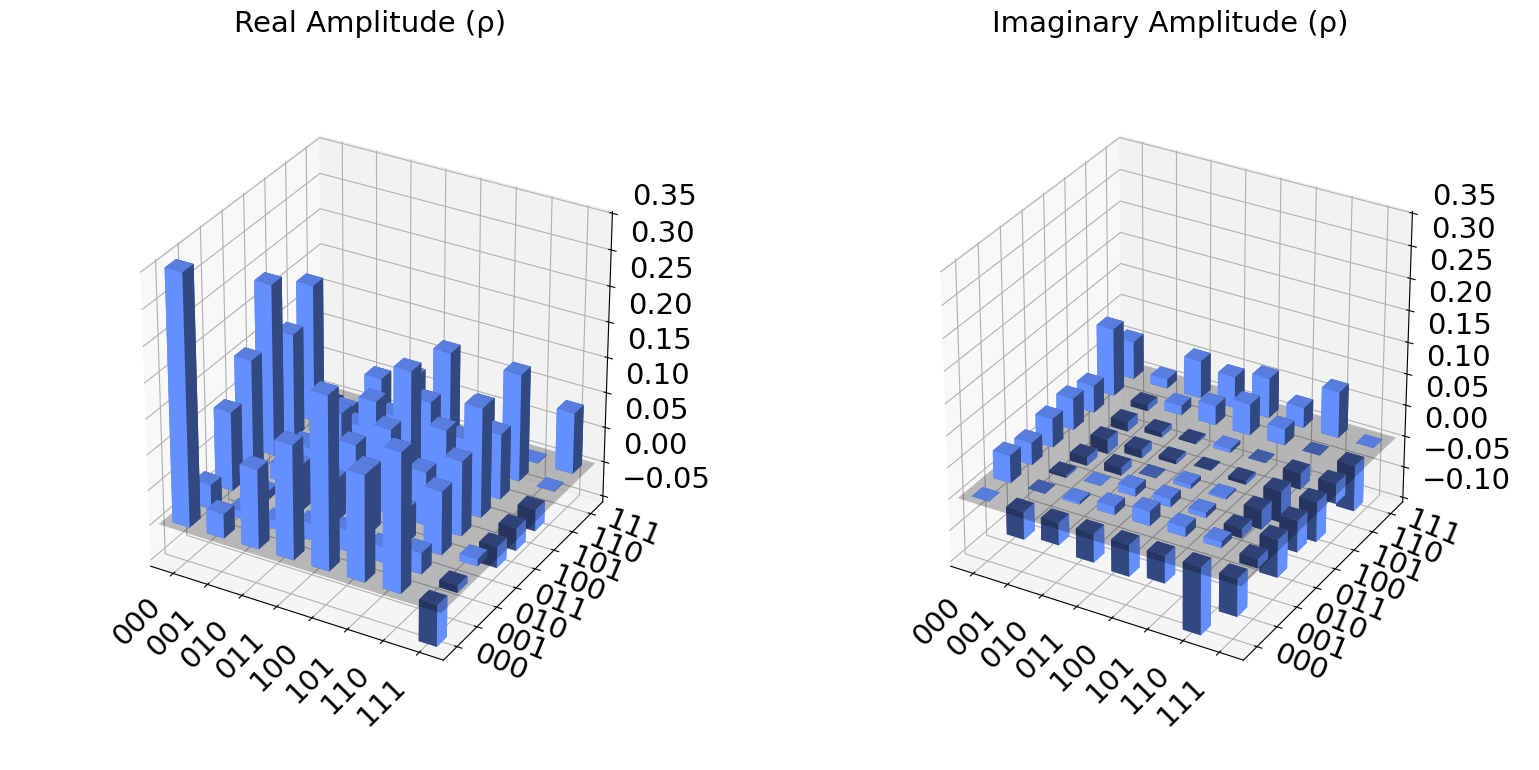

In [16]:
# State City 시각화 - 부분 대각합
plot_state_city(reduced_density_matrix.data)
plt.show()